# 0. Warming Up: Python and Mathematics from Zero

Before the first generative system, we learn the language it will be written in: enough Python to turn a list of colors and a rhythm of widths into a stripe painting, and enough mathematical notation to read the formulas ahead without flinching.

## Today's destination

By the end of this chapter you will have generated the stripe composition below yourself, from almost nothing: a list of colors, a list of widths, and one rule ("repeat across the canvas"). Along the way you will have met every basic move of the Python language that the rest of this book stands on. No experience of any kind is assumed; if you have never written a line of code, you are exactly the reader this chapter was written for.

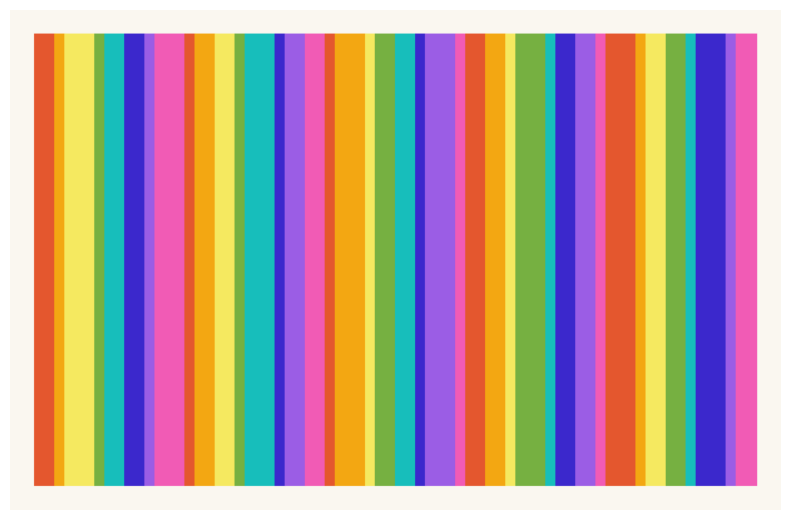

In [1]:
# display this chapter's showpiece (generated by the last cell of this notebook)
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

showpiece_path = "../assets/outputs/ch00_showpiece.png"
if os.path.exists(showpiece_path):
    image = mpimg.imread(showpiece_path)
    plt.figure(figsize=(10, 6.5))
    plt.imshow(image)
    plt.axis("off")
    plt.show()
else:
    print("Not generated yet -- run the whole notebook once and come back.")

## Context: the stripe, art's simplest instruction

Every art school begins with a warm-up. The Bauhaus called its version the **Vorkurs**, the preliminary course every student passed through before touching a loom or a brush in earnest; chapter 6 will meet its most famous color teachers. This chapter is the book's own Vorkurs. Before we can hand instructions to a machine, we need a shared language with the machine, and we will learn it by building the simplest kind of painting there is: stripes.

Do not let the simplicity fool you; some of the most serious painting of the twentieth century is made of nothing else. Beginning in 1958, **Frank Stella** painted the Black Paintings, among them *Die Fahne hoch!* (1959): nothing but parallel bands of black enamel house paint, separated by thin lines of raw canvas, following the shape of the canvas itself. Pressed a few years later, in a 1964 radio interview, about what such painting could possibly express, Stella gave the era its bluntest artist statement: "What you see is what you see." From 1958, **Gene Davis**, soon a central figure of what became known as the Washington Color School, filled canvases edge to edge with vertical stripes of flat color; Davis advised viewers not to glance at the whole painting but to "select a specific color... and take the time to see how it operates across the painting", following its rhythm the way one listens to music (he liked to compare himself to a jazz musician who plays by ear). His *Franklin's Footpath* (1972), 414 feet of stripes painted on the roadway in front of the Philadelphia Museum of Art, was billed at the time as the largest painting in the world. In Europe, **Bridget Riley** moved from her dizzying black-and-white optical works to color stripe paintings in 1967, with works such as *Chant 2* (1967) and *Late Morning* (1967–68); she works out each composition in precise studies which studio assistants then execute, an artist of instructions if there ever was one. And **Daniel Buren** has built his entire practice, since 1965, on one module: alternating white and colored vertical stripes exactly 8.7 cm wide, his "visual tool" (*outil visuel*), deployed on walls, flags, and monuments.

Here is the point for us: a stripe painting is a small amount of data plus a rule. The data: a list of colors and a list of widths. The rule: repeat across the canvas. That is precisely the shape of a program, and by the end of this chapter you will have written it as one: your own list of colors, your own rhythm of widths, executed by Python. One thing our stripes will *not* yet have is chance. Nothing today is left to the system; every stripe is exactly where you put it. Turning instructions loose, so that the system surprises its own author, is where chapter 1 begins, and it is what will make the art "generative".

## The notebook is your studio

This document is a **Jupyter notebook**, the format of every chapter in this book. It is a chain of **cells**, and cells come in two kinds: text cells like this one, and **code cells**, gray boxes that Python can execute. You run a cell by clicking it and pressing `Shift+Enter`; the result appears directly beneath it.

Three habits from day one:

1. **Run in order.** Cells build on earlier cells, so a freshly opened notebook wants to be run from the top down.
2. **Nothing can break.** Change anything, run it, see what happens. The menu command *Kernel → Restart & Run All* wipes the slate and re-runs everything in order; it is the reset button, and every chapter of this book is written so that it always works.
3. **Errors are information, not accidents.** We will produce some on purpose in a moment.

In [2]:
# your first code cell: click it, then press Shift+Enter
print("Hello! I am Python, and I follow instructions.")

Hello! I am Python, and I follow instructions.


## Values and names

Python knows several kinds of value; for art we mostly need **numbers** (whole ones like `12`, decimal ones like `2.5`) and **text** (a *string*, Zeichenkette, always inside quotes). A **variable** stores a value under a name of your choosing: after `width = 2.5`, the name `width` means that value until you assign a new one. `print(...)` shows values beneath the cell, and anything after a `#` is a **comment**: a note for humans that Python ignores.

In [3]:
# variables store values under names; print() shows them
stripes = 12
width = 2.5
artist = "Gene Davis"
print(artist, "paints", stripes, "stripes")
print("total width:", stripes * width)

Gene Davis paints 12 stripes
total width: 30.0


In [4]:
# an f-string builds text from values: an f before the quote, values in {}
color = "red"
share = 1 / 3
print(f"{share} of the stripes are {color}")
print(f"rounded to two decimals: {share:.2f}")   # :.2f rounds the display

0.3333333333333333 of the stripes are red
rounded to two decimals: 0.33


## Reading an error message

Sooner or later today, a cell will answer you with a wall of red text: a **traceback**. Rule one, worth the price of this whole chapter: **read the last line first.** It names the type of the problem and usually the exact word Python stumbled over. The two errors you will meet most often:

- `NameError: name 'artis' is not defined`: you used a name Python has never heard of. Nine times out of ten it is a typo, or the cell that defines the name has not been run yet.
- `SyntaxError`: the line is not legal Python; look for a missing quote, bracket, or colon at (or just before) the marked spot.

The cell below is broken on purpose. Remove the `#` in front of **one** commented line, run the cell, read the last line of the red answer, then put the `#` back (so the notebook still runs cleanly from top to bottom) and try the other one.

In [5]:
# broken on purpose: uncomment ONE line at a time, run, read the red answer,
# then restore the # so the notebook stays runnable top to bottom
print(artist)                        # this line works: artist exists
# print(artis)                       # NameError: a typo, no such name
# print("the quote never ends)      # SyntaxError: Python cannot parse this

Gene Davis


## Many things at once: lists

A **list** (Liste) holds many values in one name, in order. Positions count **from 0**: think "how many steps from the start", so the first element is `colors[0]`. Negative positions count from the end, `len(...)` reports the length, `.append(...)` grows the list, and a **slice** like `[1:3]` cuts out a range (from position 1 up to, not including, 3).

In [6]:
# a list holds values in order; counting starts at 0
colors = ["red", "blue", "yellow", "black"]
print("first:", colors[0])
print("last:", colors[-1])            # negative positions count from the end
print("middle two:", colors[1:3])     # a slice: position 1 up to (not incl.) 3
print("how many:", len(colors))
colors.append("cream")                # grow the list at the end
print("after append:", colors)

first: red
last: black
middle two: ['blue', 'yellow']
how many: 4
after append: ['red', 'blue', 'yellow', 'black', 'cream']


Two siblings of the list. A **tuple** is a small fixed bundle in round brackets, like a point `(3, 5)` on the canvas; write two names on the left of the `=` and Python **unpacks** it into both at once. A **dictionary** (dict) is a drawer cabinet: values are filed under *names* instead of positions. Both are everywhere in this book: every coordinate is a tuple, and the course's color palettes live in one shared dictionary.

In [7]:
# a tuple bundles values; an assignment with two names unpacks it
point = (3, 5)
x, y = point
print("x =", x, " y =", y)

# a dictionary files values under names instead of positions
moods = {"calm": "lightsteelblue", "loud": "crimson"}
print("loud ->", moods["loud"])
moods["new"] = "gold"                 # a dict can always take one more entry
print(moods)

x = 3  y = 5
loud -> crimson
{'calm': 'lightsteelblue', 'loud': 'crimson', 'new': 'gold'}


## Repetition: the for-loop

Art is repetition with variation, and repetition is the one thing computers do tirelessly. A **for-loop** (Schleife) repeats its indented lines once per element; `range(5)` supplies the counting numbers 0, 1, 2, 3, 4. The indentation is not decoration: it is how Python knows which lines belong to the loop.

**Try it:** change `range(5)` and the `1 + i` formula, and run the cell again.

In [8]:
# a loop repeats its indented lines; range(5) counts 0 to 4
for i in range(5):
    print("stripe number", i, "gets width", 1 + i)

stripe number 0 gets width 1
stripe number 1 gets width 2
stripe number 2 gets width 3
stripe number 3 gets width 4
stripe number 4 gets width 5


In [9]:
# a loop inside a loop visits every row/column combination -- remember this
for row in range(3):
    line = ""
    for col in range(6):
        line = line + "# "
    print("row", row, ":", line)

row 0 : # # # # # # 
row 1 : # # # # # # 
row 2 : # # # # # # 


## The clock trick: modulo

One small operator carries astonishing weight in this book: `%`, **modulo**, the *remainder* after whole-number division; `7 % 4` is 3. Its magic appears when a counter climbs: as `i` runs 0, 1, 2, 3, 4, 5, ..., the value `i % 4` cycles 0, 1, 2, 3, 0, 1, ...: a clock with four hours. That is how four colors can paint any number of stripes: stripe `i` gets `colors[i % len(colors)]`, around and around, forever. In a few minutes you will see this as color.

In [10]:
# i % 4 cycles like a clock: watch the middle column repeat
colors = ["red", "blue", "yellow", "black"]
for i in range(10):
    print("stripe", i, " clock", i % 4, " color", colors[i % 4])

stripe 0  clock 0  color red
stripe 1  clock 1  color blue
stripe 2  clock 2  color yellow
stripe 3  clock 3  color black
stripe 4  clock 0  color red
stripe 5  clock 1  color blue
stripe 6  clock 2  color yellow
stripe 7  clock 3  color black
stripe 8  clock 0  color red
stripe 9  clock 1  color blue


## Decisions: if, elif, else

Programs branch. `if` runs its indented lines only when a condition holds, `elif` ("else if") offers a next test, `else` catches everything left over. Conditions compare values: `==` asks "equal?" (one `=` assigns, two ask), and `<`, `>`, `<=`, `>=` work as in school.

The `while` loop is `if`'s repeating cousin: it repeats its lines *as long as* the condition holds. We will use it rarely, but you should recognize it.

In [11]:
# if / elif / else pick exactly one branch; == compares, = assigns
width = 4
if width > 4:
    print("a broad, calm stripe")
elif width == 4:
    print("a medium stripe")
else:
    print("a narrow accent stripe")

a medium stripe


In [12]:
# while repeats as long as its condition holds:
# keep adding stripes until the canvas (20 units wide) is full
widths = [3, 1, 2]
filled = 0.0
count = 0
while filled < 20:
    filled = filled + widths[count % len(widths)]   # the clock trick again
    count = count + 1
print(count, "stripes fill the canvas; total width:", filled)

10 stripes fill the canvas; total width: 21.0


## Recipes with a name: functions

A **function** (Funktion) wraps lines of code under a name, with **parameters** as its dials: `def` opens the recipe, `return` hands the result back. Two conveniences appear in every chapter of this book. A parameter can carry a **default value** (`repeat=3` in the `def` line), used whenever the caller stays silent; and callers can *name* their arguments (`rhythm(widths, repeat=2)`), which keeps calls readable once a function has many dials. One idiom to recognize on sight: a default of `None` plus a line `if widths is None:` inside means "if the caller gave nothing, build the standard one".

**Try it:** call `rhythm` with your own widths, and with and without `repeat=`.

In [13]:
# def wraps a recipe under a name; parameters are its dials
def rhythm(widths, repeat=3):
    result = []
    for r in range(repeat):
        for w in widths:
            result.append(w)
    return result

print(rhythm([3, 1, 2]))
print(rhythm([3, 1, 2], repeat=2))    # naming the argument at the call

[3, 1, 2, 3, 1, 2, 3, 1, 2]
[3, 1, 2, 3, 1, 2]


## Reading mathematics

The rest of this book teaches every mathematical idea it uses, always with a picture, at the moment it is needed. What it cannot teach in passing is *notation*: the compact costume mathematics wears. This section is a phrasebook, not a course. Skim it now, and come back whenever a formula stares at you.

**Greek letters are just names.** When formulas run out of ordinary letters they reach for Greek ones. A Greek letter carries no hidden operation; it is a variable name, exactly like `width` above, and each chapter says what its letters stand for. The cast you will actually meet:

| Letter | Name | Typical role in this book |
|:---:|---|---|
| $\alpha$ | alpha | an angle, or an opacity |
| $\theta$ | theta | an angle |
| $\pi$ | pi | the circle number, roughly 3.14159 |
| $\sigma$ | sigma | a width or a spread |
| $\mu$ | mu | a middle |
| $\lambda$ | lambda | a spacing |
| $\Delta$ | delta | a difference ($\Delta x$: "the change in x") |
| $\Sigma$ | capital sigma | "add them all up" (below) |

**Subscripts are labels, not arithmetic.** $p_x$ reads "the x part of the point $p$"; $x_i$ reads "the i-th of the x values"; in this book a small dash as in $g'$ ("g prime") just means "a second, related g". None of these marks ask you to compute anything.

**Powers and roots.** $x^2$ ("x squared", a Potenz) is `x**2` in Python: x times itself. Roots undo powers, and the square root $\sqrt{x}$ is `x**0.5`. One more thing school never dwelt on: a power *between* 0 and 1 bends values rather than exploding them, and for numbers between 0 and 1 the bend reverses: squaring pushes them down, a root lifts them up. The book will use exactly this bending, many times, to shape brightness and ink.

**Try it:** add your own values between 0 and 1 to the list in the next cell, and predict for each, before running, whether squaring pushes it down.

In [14]:
# powers in code: the ** operator; watch a power bend values in 0..1
print("3**2 =", 3**2, "   2**10 =", 2**10, "   81**0.5 =", 81**0.5)
print()
for x in [0.0, 0.25, 0.5, 0.75, 1.0]:
    print(f"x = {x:.2f}   squared: {x**2:.2f}   square root: {x**0.5:.2f}")

3**2 = 9    2**10 = 1024    81**0.5 = 9.0

x = 0.00   squared: 0.00   square root: 0.00
x = 0.25   squared: 0.06   square root: 0.50
x = 0.50   squared: 0.25   square root: 0.71
x = 0.75   squared: 0.56   square root: 0.87
x = 1.00   squared: 1.00   square root: 1.00


**Angles: degrees and radians.** School measures angles in degrees: a full turn is 360°. Mathematics and Python prefer **radians** (Bogenmaß): the distance walked along a circle of radius 1, so a full turn is $2\pi \approx 6.283$, a half turn is $\pi$, and a quarter turn ("straight up") is $\pi/2$. Same angles, different unit, like centimeters and inches; `math.radians(...)` converts. This cell also introduces the `import` move properly (the showpiece cell at the very top already ran three imports on trust): `import math` fetches Python's arithmetic toolbox, whose tools then answer to `math.something`. The plotting section below fetches the course toolbox the same way.

In [15]:
# import fetches a toolbox; math is Python's arithmetic toolbox
import math
print(f"a full turn:    360 degrees = {2 * math.pi:.3f} radians (2 pi)")
print(f"a half turn:    180 degrees = {math.radians(180):.3f} radians (pi)")
print(f"a quarter turn:  90 degrees = {math.radians(90):.3f} radians (pi/2)")

a full turn:    360 degrees = 6.283 radians (2 pi)
a half turn:    180 degrees = 3.142 radians (pi)
a quarter turn:  90 degrees = 1.571 radians (pi/2)


**The sum sign is a loop.** $\sum_i x_i$ ("sum over i") means: add them all up, one term per item. You already know it under another name:

In [16]:
# capital sigma, translated: a for-loop with a running total
values = [3, 1, 2]
total = 0
for v in values:
    total = total + v
print("the sum of", values, "is", total)
print("Python ships this loop ready-made:", sum(values))

the sum of [3, 1, 2] is 6
Python ships this loop ready-made: 6


**A logarithm counts doublings.** $\log_2(32) = 5$ because five doublings lead from 1 to 32; the logarithm answers "how many times?", and so undoes the power, since $2^5 = 32$. That is the whole idea. Chapters 8, 9 and 20 will lean on it for well-marked moments, chapter 25 for a whole singing section.

In [17]:
# how many doublings lead from 1 to 32? that count is the logarithm
n = 1
count = 0
while n < 32:
    n = n * 2
    count = count + 1
print("1 doubles to 32 in", count, "steps, so log2 of 32 is", count)
print("the toolbox agrees:", math.log2(32))

1 doubles to 32 in 5 steps, so log2 of 32 is 5
the toolbox agrees: 5.0


**Very large, very small: the `e` shorthand.** Python writes big and tiny numbers as `1e6` (a 1 followed by six zeros: one million) and `1e-9` (a 1 nine places behind the decimal point: a billionth). When `1e-9` appears in this book's code it is almost always a harmless guard: a number too small to see, there to keep some division safe.

**Mixing two numbers.** The pattern `(1 - t) * a + t * b` slides smoothly from `a` (at `t = 0`) to `b` (at `t = 1`); at `t = 0.5` it sits exactly in the middle. The book mixes colors, positions and widths with this one-liner constantly.

**Try it:** set `a, b = 255, 0` in the cell below and run it again; the same one-liner mixes any two numbers, colors included.

That is the whole phrasebook. Now, at last, to the canvas.

In [18]:
# the e shorthand, and the mixing pattern, in action
print("1e6  =", 1e6, "   2.5e-3 =", 2.5e-3)
a, b = 0, 10
for t in [0.0, 0.25, 0.5, 0.75, 1.0]:
    mixed = (1 - t) * a + t * b
    print(f"t = {t:.2f}  ->  mixed = {mixed:.1f}")

1e6  = 1000000.0    2.5e-3 = 0.0025
t = 0.00  ->  mixed = 0.0
t = 0.25  ->  mixed = 2.5
t = 0.50  ->  mixed = 5.0
t = 0.75  ->  mixed = 7.5
t = 1.00  ->  mixed = 10.0


## First light: matplotlib

**Matplotlib** is the drawing library of this whole book, and its ritual is always the same: `fig, ax = plt.subplots(...)` hands us a **figure** (the sheet of paper) and an **axes** object `ax` (the drawing area on that sheet); we place shapes and lines onto `ax`; `plt.show()` displays the result. You will also meet the shorthand style `plt.plot(...)`, which quietly draws on the current axes; both styles appear in this book and drive the same machinery.

One course convention from day one: when a plot is a **diagram**, the axis lines and numbers stay visible, because they carry information. When a plot is an **artwork**, we switch them off with `ax.axis("off")`: a painting does not need a ruler. Artworks also sit on a warm paper-white ground instead of harsh screen white, like plates in a printed book; the course package provides that tone as `PAPER`, and it provides shared color **palettes**, filed in a dictionary, as promised. The package sits one folder above the notebooks, so two lines first tell Python where to look. One vocabulary note for the palettes you are about to see: a screen color has three channels, red, green and blue, each running 0 to 255, and a string like `#E4572E` packs those three numbers in base-16 shorthand; dividing such values by 255, when you meet it later, just squeezes them into the range 0 to 1.

In [19]:
# the course toolbox: palettes and the paper ground, used in every chapter
import sys
sys.path.append("..")
from agap.helpers import PALETTES, PAPER, save_artwork

print("palettes:", list(PALETTES.keys()))
print("kelly =", PALETTES["kelly"])

palettes: ['bauhaus', 'rothko_dark', 'pastel', 'monochrome', 'viridis', 'magma', 'kelly']
kelly = ['#E4572E', '#F3A712', '#F5E960', '#76B041', '#17BEBB', '#3B28CC', '#9B5DE5', '#F15BB5']


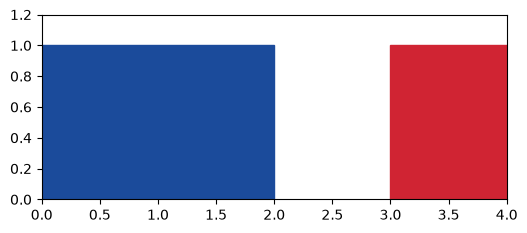

In [20]:
# a first drawing: two rectangles on an axes -- axes ON, a diagram for now
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(6, 2.4))
ax.add_patch(Rectangle((0, 0), 2, 1, color="#1B4B9B"))   # corner (x, y), width, height
ax.add_patch(Rectangle((3, 0), 1, 1, color="#D02433"))
ax.set_xlim(0, 4)
ax.set_ylim(0, 1.2)
plt.show()

`Rectangle((x, y), width, height)` takes the lower-left corner as a tuple, then the size: four numbers, one box. Everything you will draw today is made of these.

## Two bits of math you already own

**Normalization.** Any counter can be squeezed into the range 0 to 1: divide it by the largest value it reaches. In a loop over `n` stripes, `i / (n - 1)` runs from 0.0 (first stripe) to exactly 1.0 (last stripe). This tiny trick powers half the book: "how far down the canvas are we?", "how far through the rainbow?", always a number between 0 and 1. It has a visual today because matplotlib accepts a gray value written as text: `"0.0"` is black, `"1.0"` is white, so normalization *is* a gradient waiting to happen.

**The mean** (Mittelwert): the balance point of a set of numbers, their sum divided by their count. Chapter 2 leans on it.

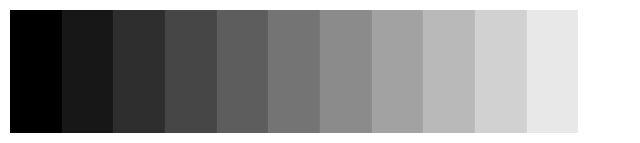

mean width: 2.4


In [21]:
# i / (n - 1) runs from 0 to 1 -- made visible as a gray gradient
n = 12
fig, ax = plt.subplots(figsize=(8, 1.6))
for i in range(n):
    gray = i / (n - 1)                # 0.0 for the first stripe, 1.0 for the last
    ax.add_patch(Rectangle((i, 0), 1, 1, color=str(gray)))
ax.set_xlim(0, n)
ax.set_ylim(0, 1)
ax.axis("off")
plt.show()

widths = [3, 1, 2, 1, 5]
print("mean width:", sum(widths) / len(widths))

## Build-up: the stripe painting

Time to assemble the chapter's machine, in three steps: equal stripes from a cycling palette, then a width rhythm, then the finished generator with every decision as a parameter.

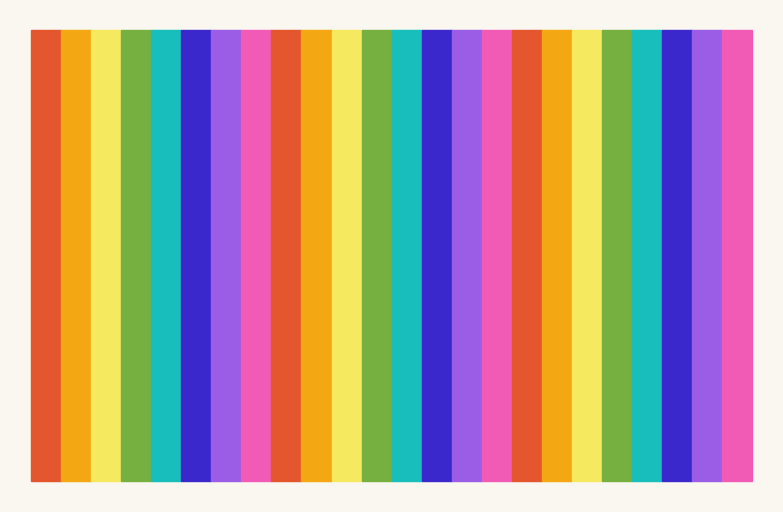

In [22]:
# step 1: equal stripes, colors cycling through the palette (the clock trick)
palette = PALETTES["kelly"]
n = 24

fig, ax = plt.subplots(figsize=(10, 6.4), facecolor=PAPER)
for i in range(n):
    ax.add_patch(Rectangle((i, 0), 1, 15, color=palette[i % len(palette)]))
ax.set_xlim(-0.7, n + 0.7)
ax.set_ylim(-0.7, 15.7)
ax.set_aspect("equal")
ax.axis("off")                        # an artwork now, not a diagram
plt.show()

Equal widths read as wallpaper: pleasant, and a little dead. A **rhythm** of widths brings the surface to life, especially when it cycles at a different period than the colors: five widths against eight colors, and the same pairing of width and color only returns after 40 stripes. Musicians call this a polyrhythm; weavers have used it forever.

**Try it:** run the cell, then change the `widths` list or the palette name and run it again.

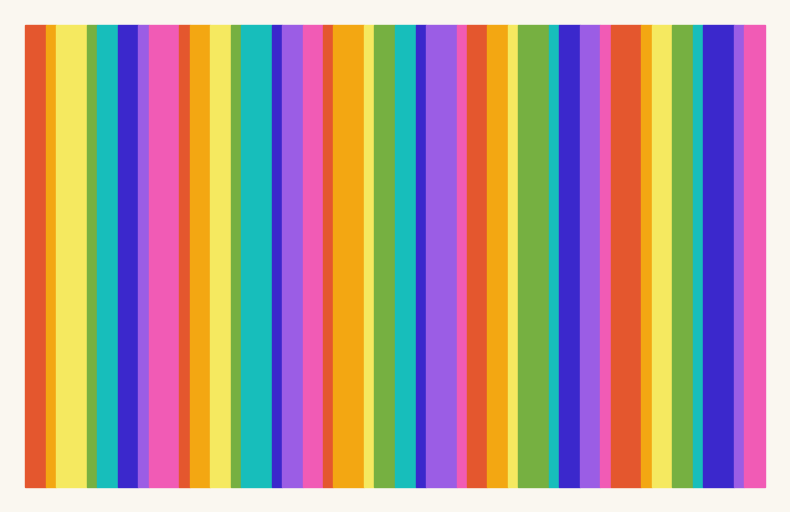

In [23]:
# step 2: a width rhythm -- x accumulates, each stripe starts where the last ended
widths = [2, 1, 3, 1, 2]
palette = PALETTES["kelly"]
n = 40

fig, ax = plt.subplots(figsize=(10, 6.4), facecolor=PAPER)
x = 0.0
for i in range(n):
    w = widths[i % len(widths)]
    ax.add_patch(Rectangle((x, 0), w, 45, color=palette[i % len(palette)]))
    x = x + w
ax.set_xlim(-1.5, x + 1.5)
ax.set_ylim(-1.5, 46.5)
ax.set_aspect("equal")
ax.axis("off")
plt.show()

## Playground

The finished generator: the build-up wrapped into one function whose parameters are all in one place. Note the `widths=None` idiom from the functions section, in the wild for the first time.

In [24]:
# the finished generator: a stripe painting from a palette and a width rhythm
def stripe_painting(palette_name="kelly", widths=None, n_stripes=40,
                    height=45, margin=1.5):
    if widths is None:                # no rhythm given? use the house rhythm
        widths = [2, 1, 3, 1, 2]
    palette = PALETTES[palette_name]
    total = 0.0
    for i in range(n_stripes):
        total = total + widths[i % len(widths)]
    fig, ax = plt.subplots(figsize=(10, 10 * (height + 2 * margin) / (total + 2 * margin)),
                           facecolor=PAPER)
    x = 0.0
    for i in range(n_stripes):
        w = widths[i % len(widths)]
        ax.add_patch(Rectangle((x, 0), w, height, color=palette[i % len(palette)]))
        x = x + w
    ax.set_xlim(-margin, total + margin)
    ax.set_ylim(-margin, height + margin)
    ax.set_aspect("equal")
    ax.axis("off")
    plt.show()
    return fig

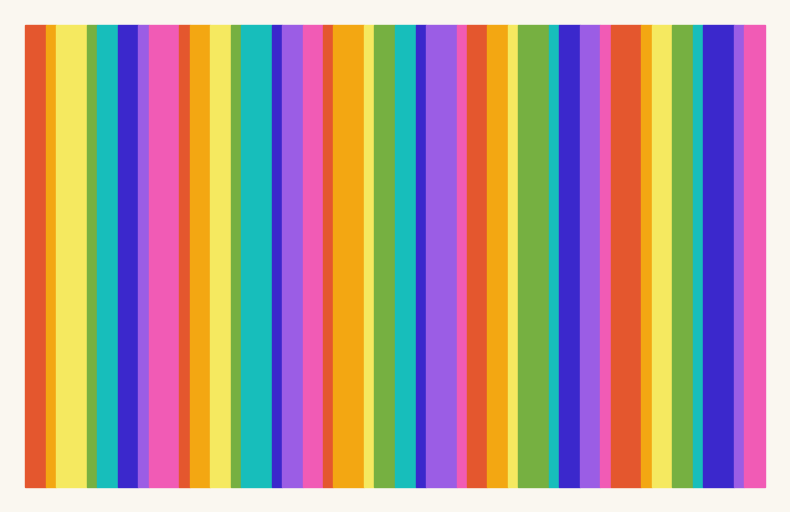

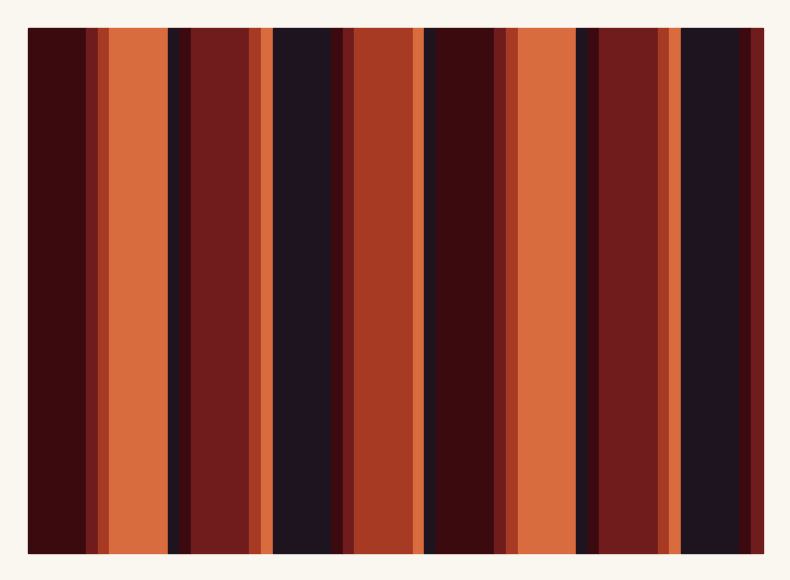

In [25]:
# temperament 1 and 2: the full spectrum rhythm vs dark fields with thin accents
art_1 = stripe_painting(palette_name="kelly")
art_2 = stripe_painting(palette_name="rothko_dark", widths=[5, 1, 1], n_stripes=27)

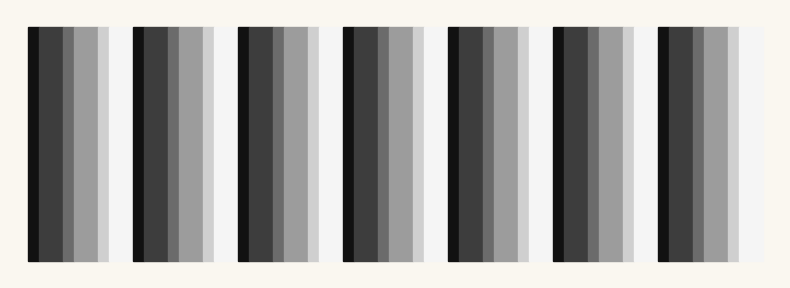

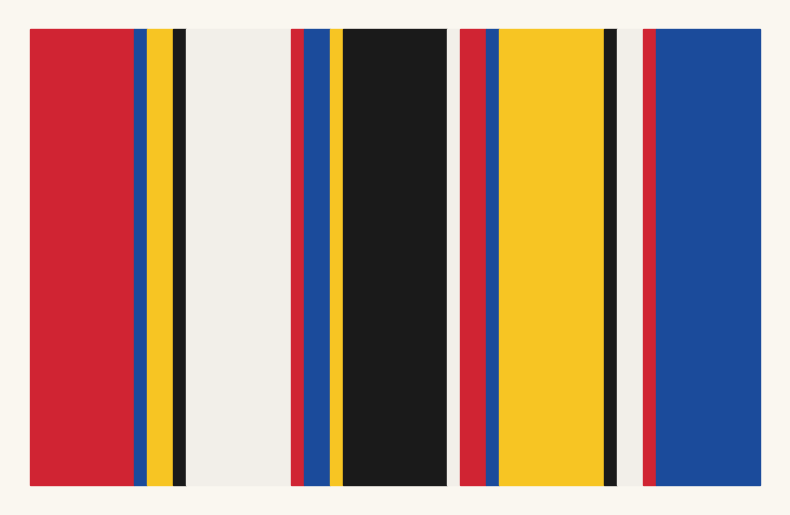

In [26]:
# temperament 3 and 4: a quiet gray polyrhythm vs broad Bauhaus banners
art_3 = stripe_painting(palette_name="monochrome", widths=[1, 2], n_stripes=42, height=20)
art_4 = stripe_painting(palette_name="bauhaus", widths=[8, 1, 2, 1], n_stripes=17, height=35)

**Look and compare.** Four rhythms, four temperaments. Which feels calmest, which most nervous, and is the palette or the width rhythm doing more of the work? `art_3` uses only two widths and six grays, yet its pattern takes twelve stripes to come back around: cover part of it and try to point at the repeat. And carry one question into chapter 1: not a single number in these four pictures is random; every stripe is exactly where the lists put it. Would a stranger at the gallery believe that?

## Export your artwork

Every chapter of this book ends at this ritual: tune the parameters until the piece feels like yours, replace `yourname` with your name, and run the cell. A print-quality PNG lands in `assets/outputs/`, which becomes your personal gallery over the course of the book (the `save_artwork` helper takes care of size and resolution).

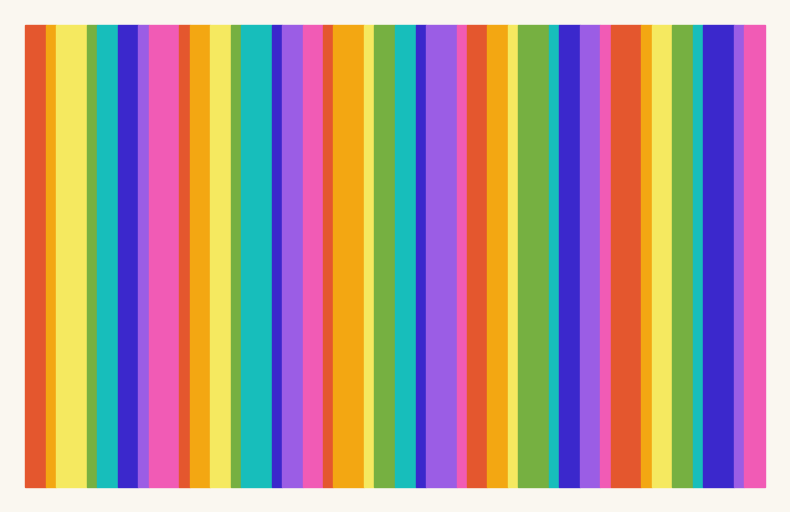

saved: assets/outputs/ch00_yourname.png


In [27]:
# save YOUR artwork: adjust parameters, replace 'yourname', run the cell
my_artwork = stripe_painting(palette_name="kelly", widths=[2, 1, 3, 1, 2])
saved_path = save_artwork(my_artwork, "yourname", chapter=0)

## Exercises

**(a) Parameter exploration: find your rhythm.** Run `stripe_painting` with widths of `[1]`, `[1, 4]`, `[1, 1, 8]`, and `[3, 3, 1, 1, 1]`. Which feels calm, which marches, which stumbles? Somewhere in your experiments the painting will stop feeling composed and start feeling arbitrary, even though no chance is involved anywhere. Note where that happened; chapter 1 picks the thought up.

**(b) Code modification: rotate the canvas.** Make the stripes run **horizontally**. In `stripe_painting`, every stripe is `Rectangle((x, 0), w, height)`: a box whose corner walks to the right. Let the corner walk *upward* instead: the width becomes the full canvas width, the walking coordinate becomes y, and the two `set_xlim`/`set_ylim` calls trade contents.

<details><summary>Solution</summary>

```python
def stripe_painting_horizontal(palette_name="kelly", widths=None, n_stripes=40,
                               width=45, margin=1.5):
    if widths is None:
        widths = [2, 1, 3, 1, 2]
    palette = PALETTES[palette_name]
    total = 0.0
    for i in range(n_stripes):
        total = total + widths[i % len(widths)]
    fig, ax = plt.subplots(figsize=(10, 10 * (total + 2 * margin) / (width + 2 * margin)),
                           facecolor=PAPER)
    y = 0.0
    for i in range(n_stripes):
        h = widths[i % len(widths)]
        ax.add_patch(Rectangle((0, y), width, h, color=palette[i % len(palette)]))
        y = y + h
    ax.set_xlim(-margin, width + margin)
    ax.set_ylim(-margin, total + margin)
    ax.set_aspect("equal")
    ax.axis("off")
    plt.show()
    return fig

stripe_painting_horizontal()
```

The corner now walks in y, and the figure's width-to-height ratio flips along: the wide format turns tall. The same rhythm reads differently on its side; horizontals settle like strata, verticals stand like figures.
</details>

**(c) Creative challenge: your name as a painting.** Encode your first name as a width rhythm: `a` is 1, `b` is 2, ... `z` is 26. The snippet below translates the letters; feed the result to `stripe_painting`, choose the palette that suits you, and give the piece a title worthy of a gallery wall.

```python
alphabet = "abcdefghijklmnopqrstuvwxyz"
name = "vera"
widths = []
for letter in name:
    widths.append(alphabet.index(letter) + 1)
```

## Further reading

- The official Python tutorial, chapter 3, ["An Informal Introduction to Python"](https://docs.python.org/3/tutorial/introduction.html): numbers, strings, and lists straight from the source; read it after this chapter, not before.
- Allen B. Downey, [*Think Python*, 3rd edition](https://allendowney.github.io/ThinkPython/) (2024, free online): the gentlest thorough introduction to the language; its first chapters cover today's ground at walking pace.
- *Bridget Riley: The Stripe Paintings 1961–2014* (David Zwirner Books, 2014): what stripes alone can carry, across five decades; the [Tate artist page](https://www.tate.org.uk/art/artists/bridget-riley-1845) is the free companion.
- [Gene Davis at the Smithsonian American Art Museum](https://americanart.si.edu/artist/gene-davis-1147): biography, quotes, and the museum's major Davis holdings, including his advice on how to look at a stripe painting.

---
### Appendix: regenerate the showpiece

This last cell (re)creates the image shown at the top of the notebook. It runs automatically with *Restart & Run All*.

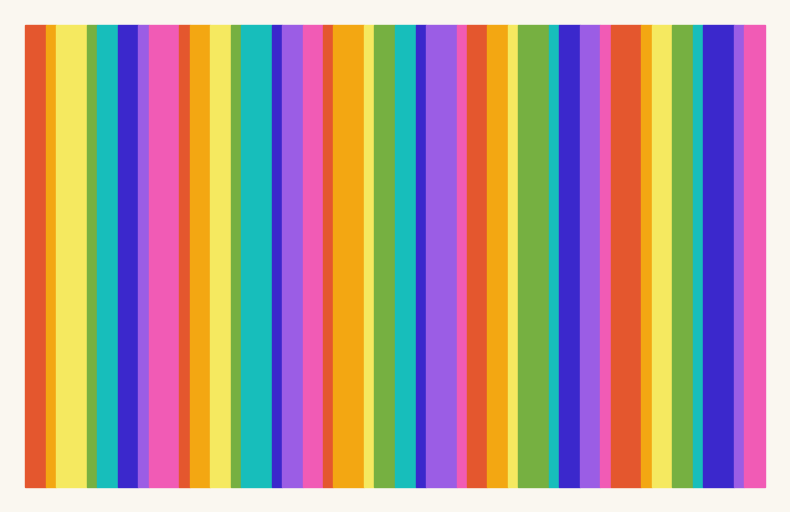

saved: assets/outputs/ch00_showpiece.png


In [28]:
# regenerate this chapter's showpiece: the kelly polyrhythm
showpiece = stripe_painting(palette_name="kelly", widths=[2, 1, 3, 1, 2], n_stripes=40)
saved_path = save_artwork(showpiece, "showpiece", chapter=0)